In [1]:
# --- Imports ---
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
from scipy.integrate import odeint
from scipy.stats.qmc import LatinHypercube

In [2]:
# --- Data Generation ---
g_const = 9.81
initial_state = [np.pi/4, 0.0]

def rhs(state, t, L, g):
    theta, theta_dot = state
    return [theta_dot, -(g / L) * np.sin(theta)]

def generate_trajectory(L, t_end, num_points):
    t_arr = np.linspace(0, t_end, num_points)
    states = odeint(rhs, initial_state, t_arr, args=(L, g_const))
    return t_arr.reshape(-1, 1), np.full_like(t_arr, L).reshape(-1, 1), states[:, 0:1]

# Time horizon to ensure multiple cycles
t_end = 10.0
resolution = 1000 # High resolution for the exact curves

# 1. Training Data (L bounds: [0.5, 2.0])
np.random.seed(42)
L_train_vals = [0.5, 0.875, 1.25, 1.625, 2.0]
X_train_list, theta_train_list = [], []

for L in L_train_vals:
    t_arr, L_arr, theta_arr = generate_trajectory(L, t_end, resolution)
    # Sample 40 sparse points across the 10 seconds for each length
    t_samp, L_samp, theta_samp = t_arr[0::25], L_arr[0::25], theta_arr[0::25]
    theta_samp += np.random.normal(0, 0.02, size=theta_samp.shape) # Add noise
    
    X_train_list.append(np.hstack([t_samp, L_samp]))
    theta_train_list.append(theta_samp)

X_train = np.vstack(X_train_list)
theta_train = jnp.array(np.vstack(theta_train_list))

# 2. Multiple Interpolations (Lengths inside [0.5, 2.0])
L_interp_vals = [0.7, 1.0, 1.5]
interp_data = [generate_trajectory(L, t_end, resolution) for L in L_interp_vals]

# 3. Multiple Extrapolations (Lengths outside [0.5, 2.0])
L_extrap_vals = [0.25, 2.5, 3.0]
extrap_data = [generate_trajectory(L, t_end, resolution) for L in L_extrap_vals]

# 4. Expanded Collocation Points Cloud
# We increase to 2000 points because the t and L domains are much larger now
lhs = LatinHypercube(d=2, seed=0)
samples = lhs.random(n=2000)
t_col = (0.0 + (t_end - 0.0) * samples[:, 0]).flatten()
L_col = (0.25 + (3.0 - 0.25) * samples[:, 1]).flatten()

In [3]:
# --- ARCHITECTURE & PHYSICS RESIDUAL ---
def init_params(key, layers):
    keys = jax.random.split(key, len(layers) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
        W = jax.random.uniform(k, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
        B = jnp.zeros((n_out,))
        params.append({'W': W, 'B': B})
    return params

def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        X = jax.nn.tanh(jnp.dot(X, layer['W']) + layer['B'])
    return jnp.dot(X, last['W']) + last['B']

# Scalar version of the network for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

# Vectorize the scalar residual function for batch processing
r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

# --- CELL 4: LOSS FUNCTIONS ---
@jax.jit
def loss_DDNN(params, X, theta_true):
    theta_pred = NN(X, params)
    return jnp.mean((theta_true - theta_pred)**2)

@jax.jit
def loss_PINN(params, X, theta_true, t_c, L_c):
    data_loss = loss_DDNN(params, X, theta_true)
    physics_loss = jnp.mean(r_PINN_vmap(params, t_c, L_c)**2)
    return data_loss + 0.001 * physics_loss

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.7981 | PINN L2: 0.8099
Train L=1.25 | DDNN L2: 0.6177 | PINN L2: 0.6105
Train L=2.00 | DDNN L2: 0.3590 | PINN L2: 0.3008

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.7307 | PINN L2: 0.7433
L=1.00 | DDNN L2: 0.6585 | PINN L2: 0.6569
L=1.50 | DDNN L2: 0.5362 | PINN L2: 0.4993

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.0480 | PINN L2: 1.0311
L=2.50 | DDNN L2: 0.5701 | PINN L2: 0.3701
L=3.00 | DDNN L2: 0.9635 | PINN L2: 0.6936


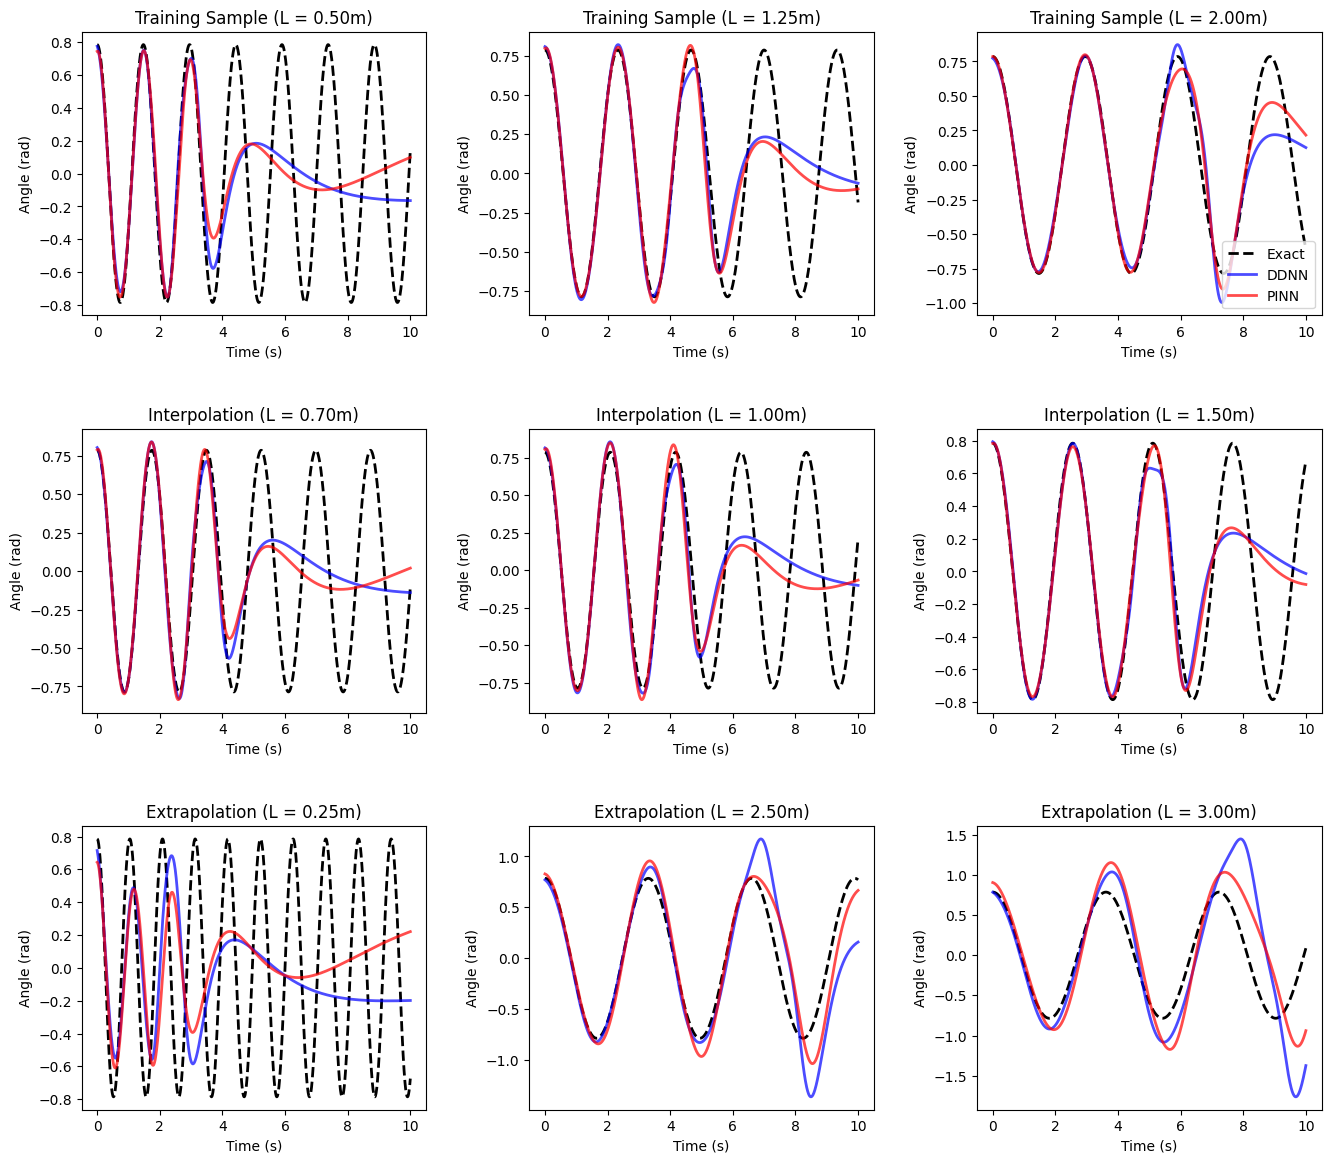

In [ ]:
# --- TRAINING LOOP 5000 Steps - Model (2, 20, 20, 20, 20, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.7447 | PINN L2: 0.8331
Train L=1.25 | DDNN L2: 0.3786 | PINN L2: 0.5576
Train L=2.00 | DDNN L2: 0.1307 | PINN L2: 0.2133

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6842 | PINN L2: 0.7647
L=1.00 | DDNN L2: 0.6273 | PINN L2: 0.6647
L=1.50 | DDNN L2: 0.2611 | PINN L2: 0.4353

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.1253 | PINN L2: 1.0691
L=2.50 | DDNN L2: 0.5801 | PINN L2: 0.3379
L=3.00 | DDNN L2: 1.0319 | PINN L2: 0.6065


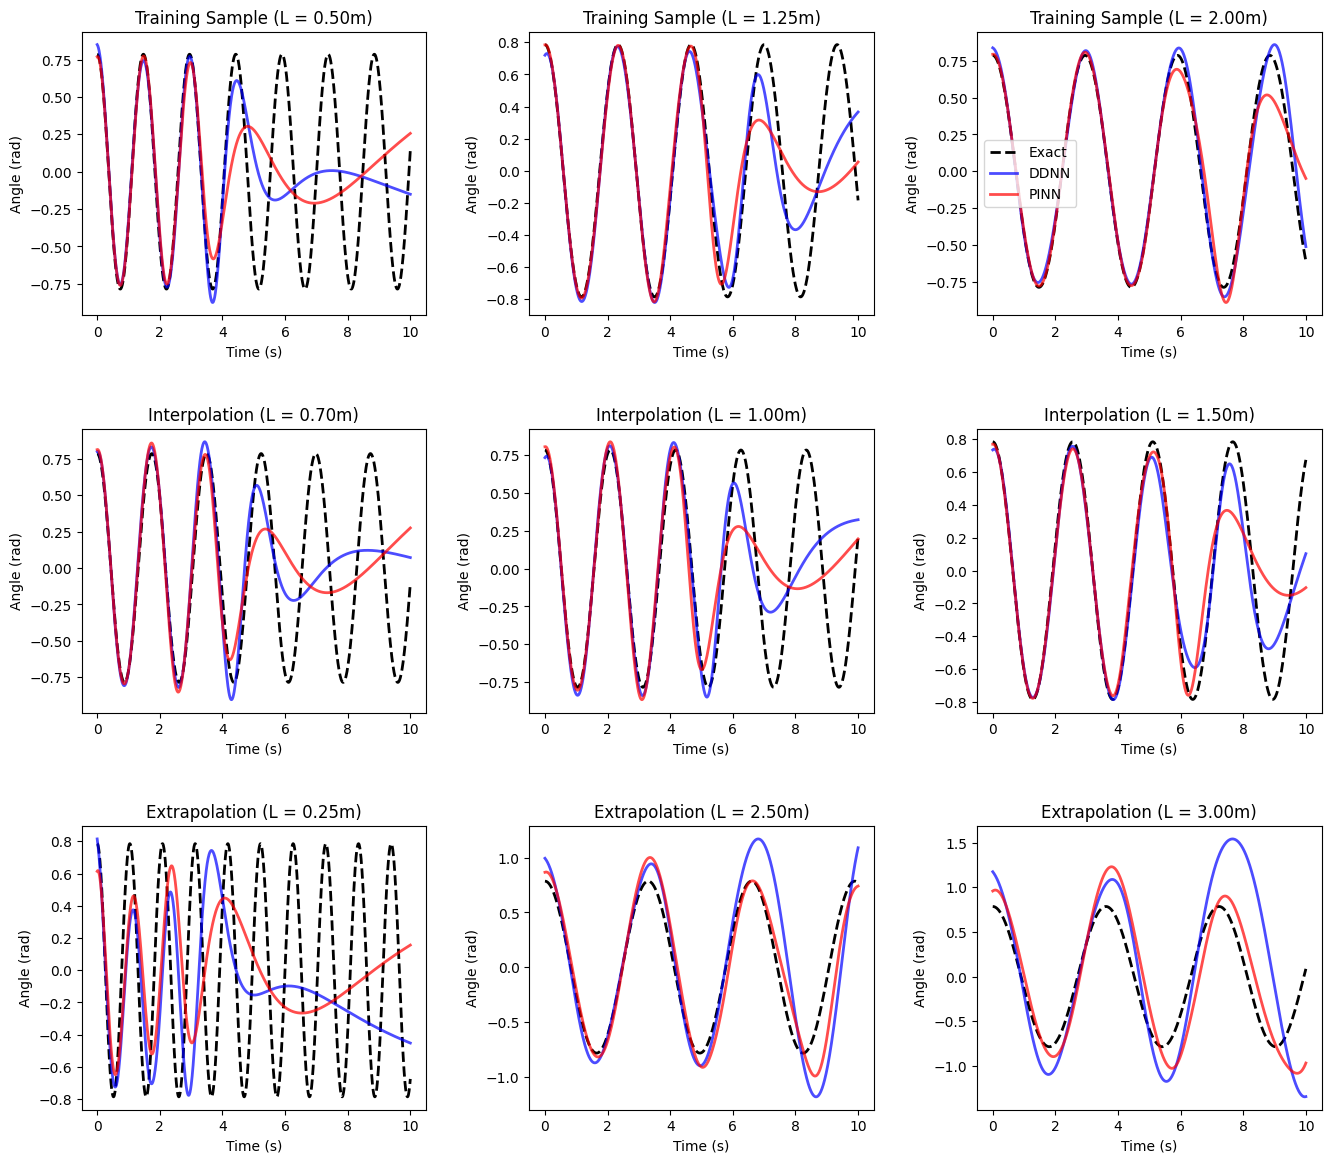

In [ ]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 20, 20, 20, 20, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Parametric Model (2, 20, 20, 20, 20, 1) - 5,000 & 10,000 Training Steps

When analyzing the results, a key pattern that stands out is that both models consistently lose predictive accuracy over longer time horizons. Furthermore, unlike the model trained from the original single-pendulum research, our parameterized model struggles to track its training data perfectly. This is likely due to the network needing to generalize across varying rod lengths ($L$), meaning it cannot rely on memorizing a single fixed frequency.

Interestingly, both models maintain high accuracy close to $t = 0$. This initial precision occurs because the data is heavily anchored to the starting angle, significantly reducing variance at the boundary. However, as the time horizon increases, both models eventually default to predicting the mean. 

While we initially hypothesized that increasing the training steps from 5,000 to 10,000 might resolve this, empirical testing showed only negligible improvement, suggesting this is a limitation of network capacity rather than a shortage of epochs. We suspect that under standard Mean Squared Error (MSE) loss, the optimizer finds it "safer" to collapse toward the mean to minimize global error once phase synchronization is lost over time. 

To address this, our next step will be to increase the physics regularization weight and expand the network's hidden layer capacity to better handle multi-cycle 2D dynamics.

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.6862 | PINN L2: 0.5991
Train L=1.25 | DDNN L2: 0.2510 | PINN L2: 0.1038
Train L=2.00 | DDNN L2: 0.0543 | PINN L2: 0.0258

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6141 | PINN L2: 0.5049
L=1.00 | DDNN L2: 0.5602 | PINN L2: 0.2424
L=1.50 | DDNN L2: 0.0878 | PINN L2: 0.0361

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.5096 | PINN L2: 1.0621
L=2.50 | DDNN L2: 0.2318 | PINN L2: 0.1496
L=3.00 | DDNN L2: 0.3675 | PINN L2: 0.3512


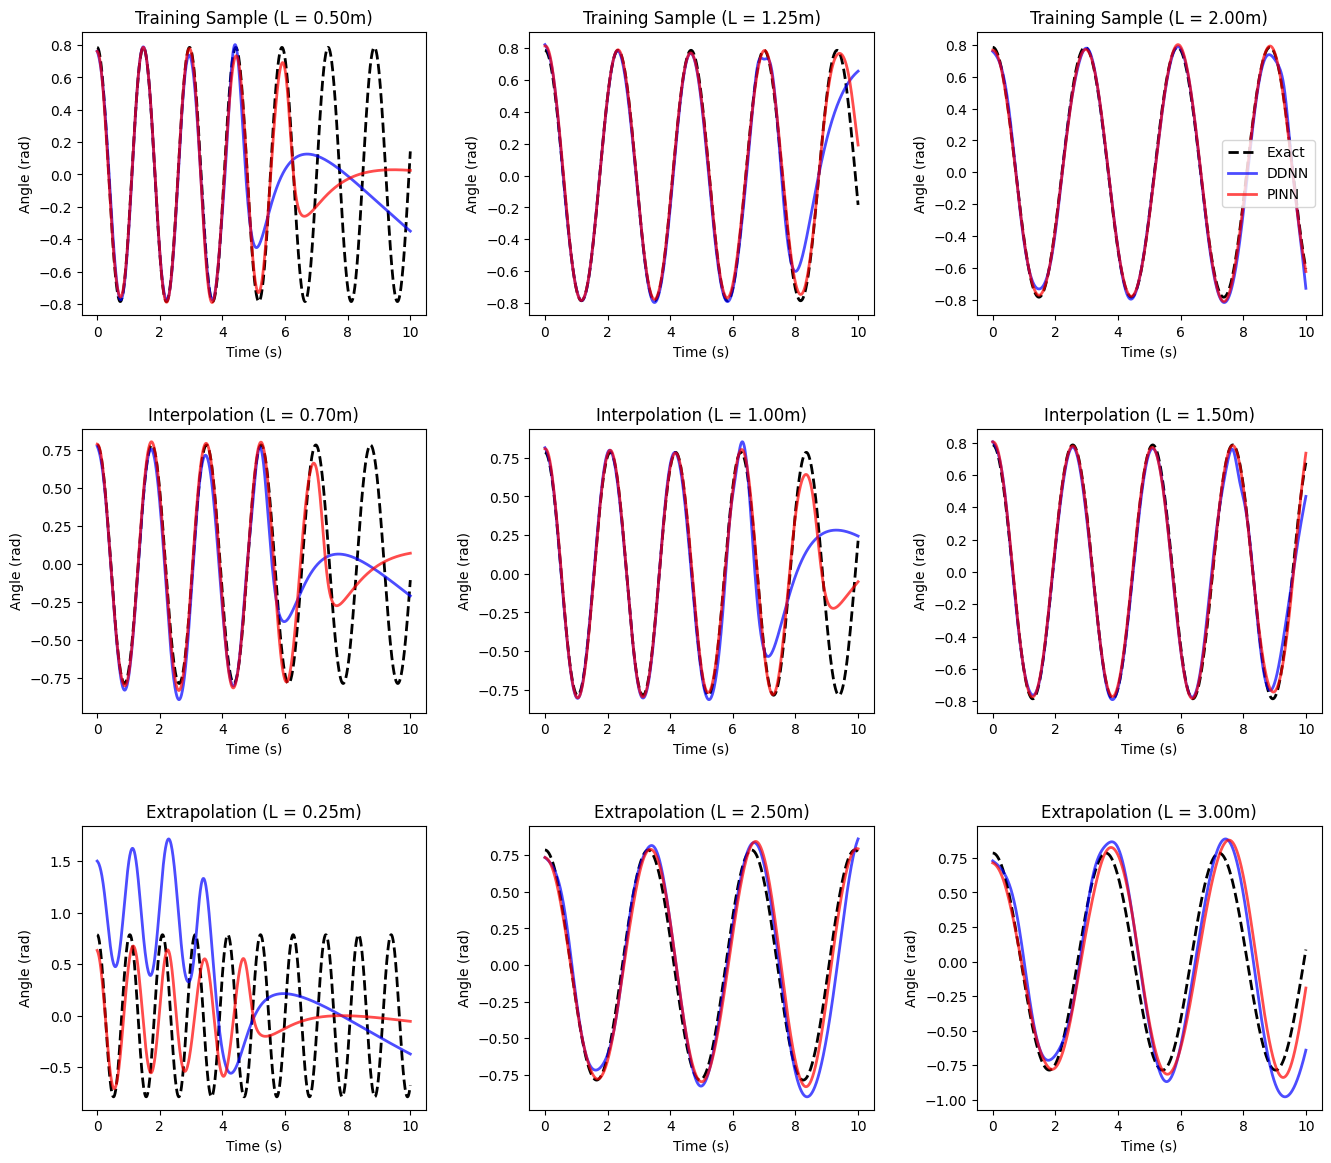

In [ ]:
# --- TRAINING LOOP 5000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.8696 | PINN L2: 0.8873
Train L=1.25 | DDNN L2: 0.6960 | PINN L2: 0.7333
Train L=2.00 | DDNN L2: 0.5461 | PINN L2: 0.6223

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.8249 | PINN L2: 0.8441
L=1.00 | DDNN L2: 0.7733 | PINN L2: 0.7918
L=1.50 | DDNN L2: 0.6787 | PINN L2: 0.7011

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.0101 | PINN L2: 0.9997
L=2.50 | DDNN L2: 0.5061 | PINN L2: 0.5924
L=3.00 | DDNN L2: 0.5895 | PINN L2: 0.6253


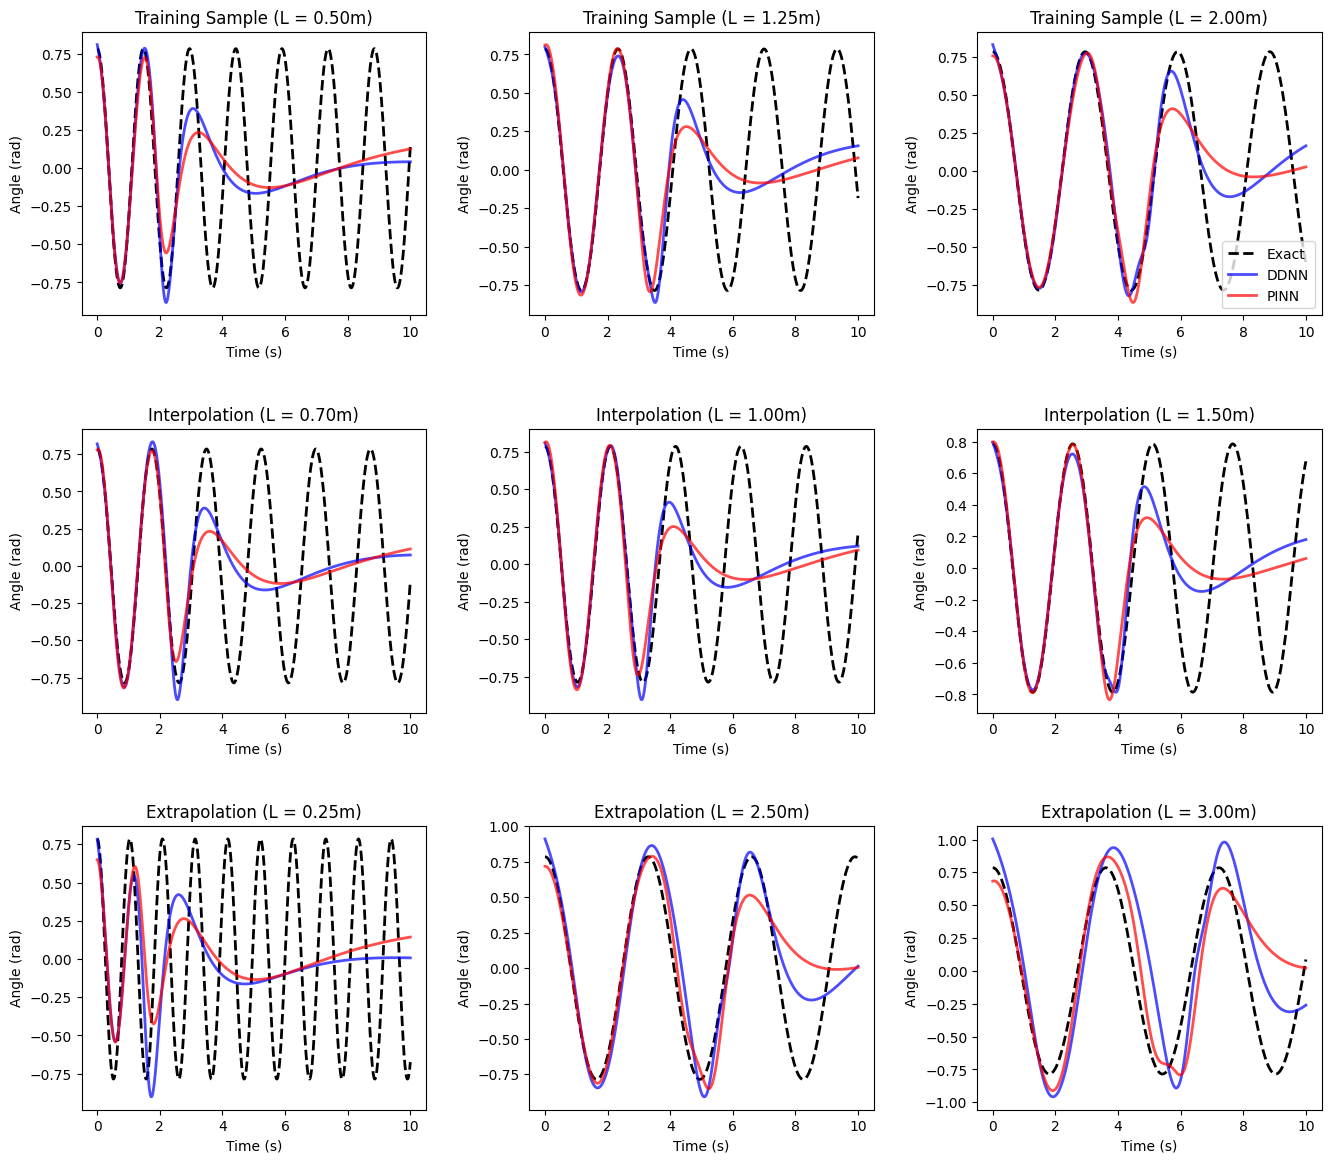

In [ ]:
# --- TRAINING LOOP 5000 Steps - Model (2, 20, 20, 20, 20, 20, 20, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.5174 | PINN L2: 0.4869
Train L=1.25 | DDNN L2: 0.0491 | PINN L2: 0.0490
Train L=2.00 | DDNN L2: 0.0283 | PINN L2: 0.0509

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6905 | PINN L2: 0.2752
L=1.00 | DDNN L2: 0.3044 | PINN L2: 0.0933
L=1.50 | DDNN L2: 0.0395 | PINN L2: 0.0522

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.4739 | PINN L2: 1.0921
L=2.50 | DDNN L2: 0.1326 | PINN L2: 0.1210
L=3.00 | DDNN L2: 0.2278 | PINN L2: 0.2700


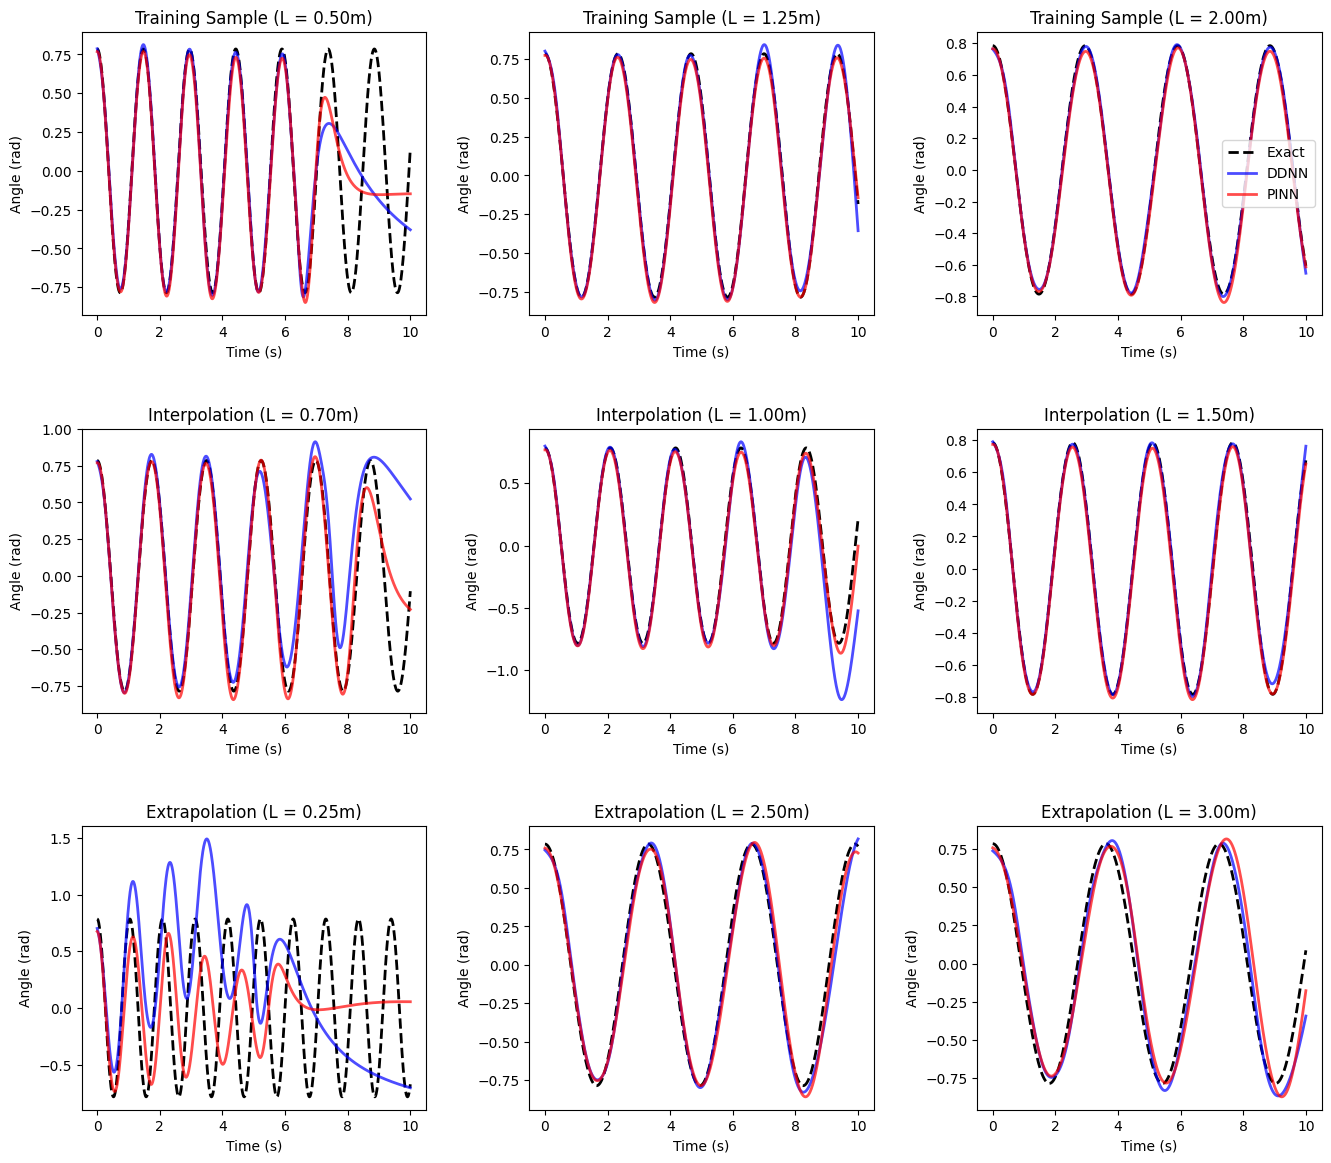

In [8]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.1925 | PINN L2: 0.1337
Train L=1.25 | DDNN L2: 0.0271 | PINN L2: 0.0360
Train L=2.00 | DDNN L2: 0.0313 | PINN L2: 0.0296

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.2645 | PINN L2: 0.0878
L=1.00 | DDNN L2: 0.0795 | PINN L2: 0.0445
L=1.50 | DDNN L2: 0.0414 | PINN L2: 0.0414

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.3238 | PINN L2: 1.1663
L=2.50 | DDNN L2: 0.1105 | PINN L2: 0.1074
L=3.00 | DDNN L2: 0.2704 | PINN L2: 0.2582


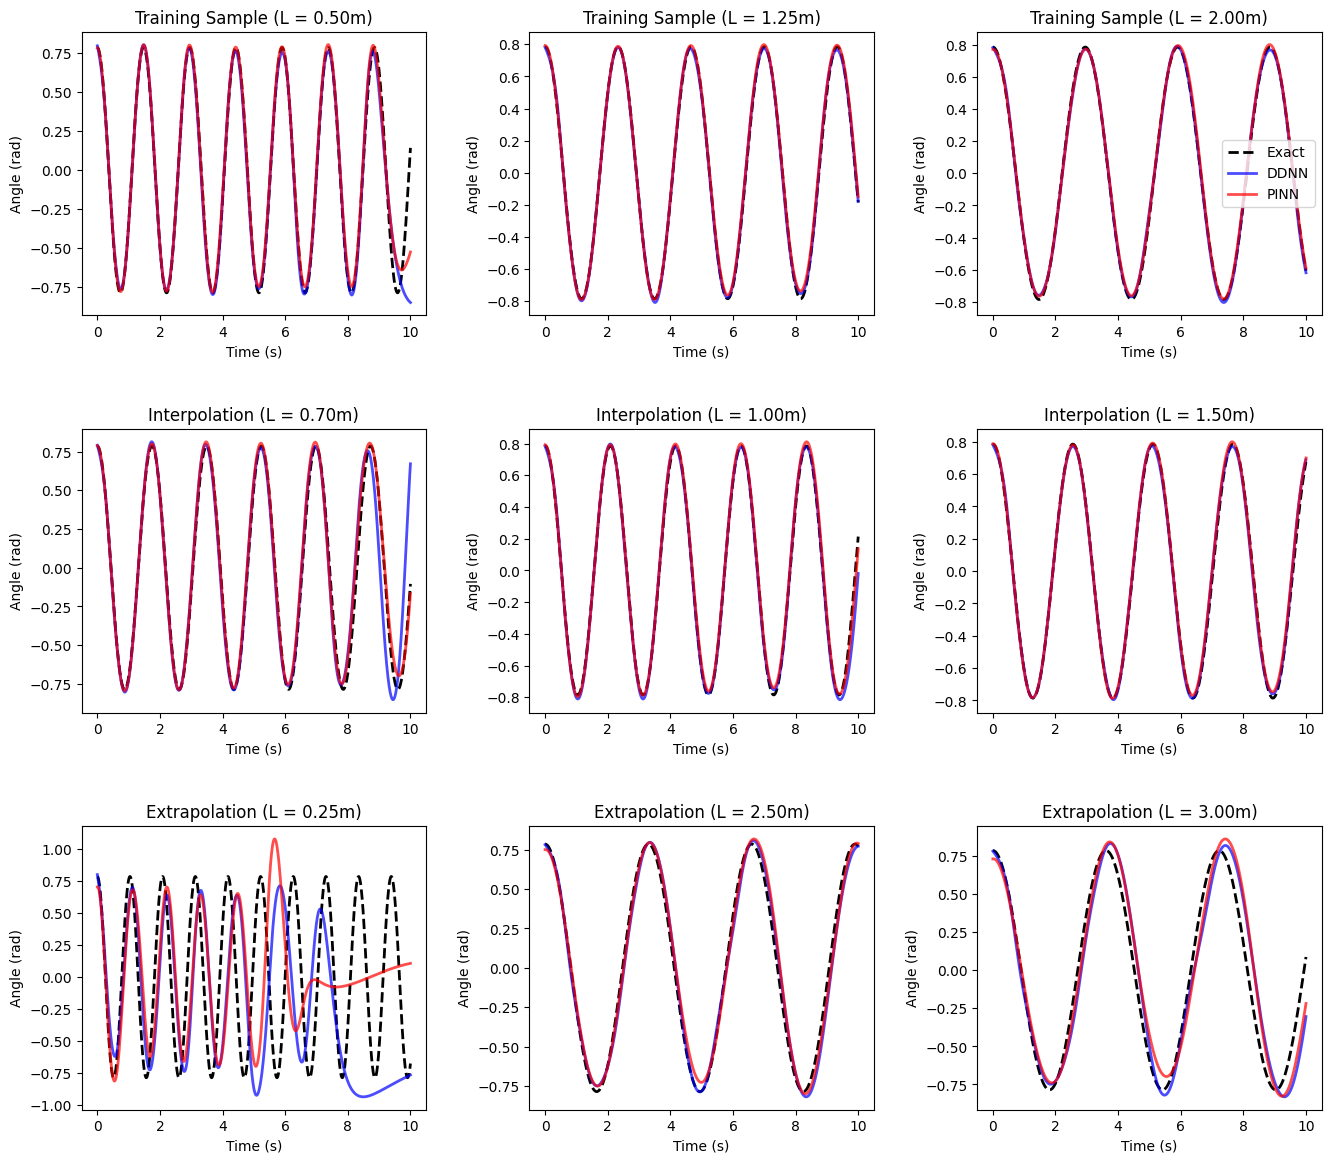

In [9]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 128, 128, 128, 128, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Model (2, 64, 64, 64, 64, 1) - Model (2, 128, 128, 128, 128, 1) - Model (2, 20, 20, 20, 20, 20, 20, 1) - 5,000 & 10,000 Training Steps

In an attempt to improve accuracy we tested two key things, one was increasing model width (increasing number of neurons per layer), and the other was increasing model depth (increase the number of layers). When increasing model depth we actually saw a regression in accuracy, which was likely due to the model becoming too deep making the optimization landscape highly complex and not smoothly traversable. Unlike depth however, increasing model width showed significant improvement, with the prediction line smoothly tracking lower frequency pendulums (High $L$), but still falling short when it came to higher frequency pendulums. A key thing to question though is whether for the lower frequency patterns the prediction line would've fallen over a longer time horizon. This is highly likely since in the higher frequency pattern for interpolation we can see the prediction line follow smoothly for a while until it eventually begins to fall back on the mean.

Looking at the results there's three big things to try next. First is to test wether making the network into a residual network can make increasing depth a viable improvement. Second is at which point can we no longer continue to scale towards more and more accurate models (which we have already seen that going from 64 - 128 neuron layers showed minimal improvement as we can already begin to see the prediction line falling out of phase a bit at the end of the high frequency interpolation pattern), meaning at what point do the returns of increasing things like width and depth being to plateu. Lastly, can increasing the physics regularization weight help the model try harder to learn frequency patterns rather then fall back on predicting averages.